In [16]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import random

from utils_1sig import *
from embeds_utils import LoadData as LoadData_embed
from embeds_utils import plot_stephist_with_ratio_v1
#from embeds_utils import plot_log_sbs

In [17]:
nv  = np.array([ -0.25,0.25])
nbg,nref = 1500000,1500000 #10000,50000
file_path = "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/Run10.7/nv0.25_0.5_l0.5_lr2e-06_r1e-06/embedding.npz"

para_model_path = "/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/Run10.7/nv0.25_0.5_l0.5_lr2e-06_r1e-06/final_models/linear_3_final.pth"
epochs = 55
batch_size = 3000
run_num = 9

feature,target = load_data(nv=nv,
                           filename = file_path,
                           N_Bkg_Pois = nbg,
                           N_ref = nref,
                           alt_name = False,
                           nv_std = np.std([-0.5,-0.25,0.25,0.5]))

ds, dl, X, true, model, num_blocks, patience = prepare_training(feature = feature,target = target, 
                 load_model=True,
                 load_model_path = para_model_path,                                                                
                 total_epochs = epochs,
                 patience = 5,
                 batch_size = batch_size,
                 model_name="linear")

In [18]:
#Defining hyperparameters
epochs = 80
learning_rate =  0.85e-6
regularization = 0.0000001e-6

device = next(model.parameters()).device  
expo_loss = ExpoLoss().to(device)
history,epoch_ix  = [],[]    # last loss of each block
optimizer = torch.optim.AdamW([{"params": [p for p in model.parameters() if p.requires_grad],
         "lr": learning_rate, "weight_decay":regularization} ])
model.train()
num_blocks  = 16
for i in range(num_blocks):
    last_epoch_loss = None
    
    for e in range(patience):

        running_loss, nseen = 0.0, 0
        
        for xb, tb in dl:
            
            xb, tb = xb.to(device), tb.to(device)
            optimizer.zero_grad() 
            pred = model(xb,tb)
            loss = expo_loss(tb,pred) 
            loss.backward()
            optimizer.step()
            model.apply(clip_weights) 
            running_loss += loss.item() * xb.size(0) # xb.size = batch size
            nseen += xb.size(0)  #total num of samples processed so far
            
        last_epoch_loss = running_loss / max(nseen, 1) 
        
        print(last_epoch_loss)

    k = patience * (i + 1)
    history.append(last_epoch_loss)
    epoch_ix.append(k)
    print(f"epoch: {k}, loss: {last_epoch_loss:.8f}")

0.2497214689925313
0.24972145352512598
0.24972149302065372
0.24972114769369363
0.24972138798236848
epoch: 5, loss: 0.24972139
0.24972124357521533
0.24972140092402698
0.24972120000422002
0.2497210899889469
0.24972108452022077
epoch: 10, loss: 0.24972108
0.24972103893011807
0.24972107841819524
0.2497209558337927
0.24972086599469184
0.24972097223252057
epoch: 15, loss: 0.24972097
0.24972083497792483
0.2497210504859686
0.24972086592763662
0.249720727160573
0.24972071214020253
epoch: 20, loss: 0.24972071
0.24972064747661352
0.2497207419797778
0.2497207295000553
0.24972063337266445
0.249720619417727
epoch: 25, loss: 0.24972062
0.24972034960240125
0.24972042835503816
0.24972055146098138
0.24972017367184163
0.24972047195583583
epoch: 30, loss: 0.24972047
0.24972037400305272
0.2497203241959214
0.24972011594474317
0.24972008416801691
0.24972018484771252
epoch: 35, loss: 0.24972018
0.24972026607394218
0.24972023969888688
0.24972015204280615
0.2497200690507889
0.24972005285322665
epoch: 40, loss: 

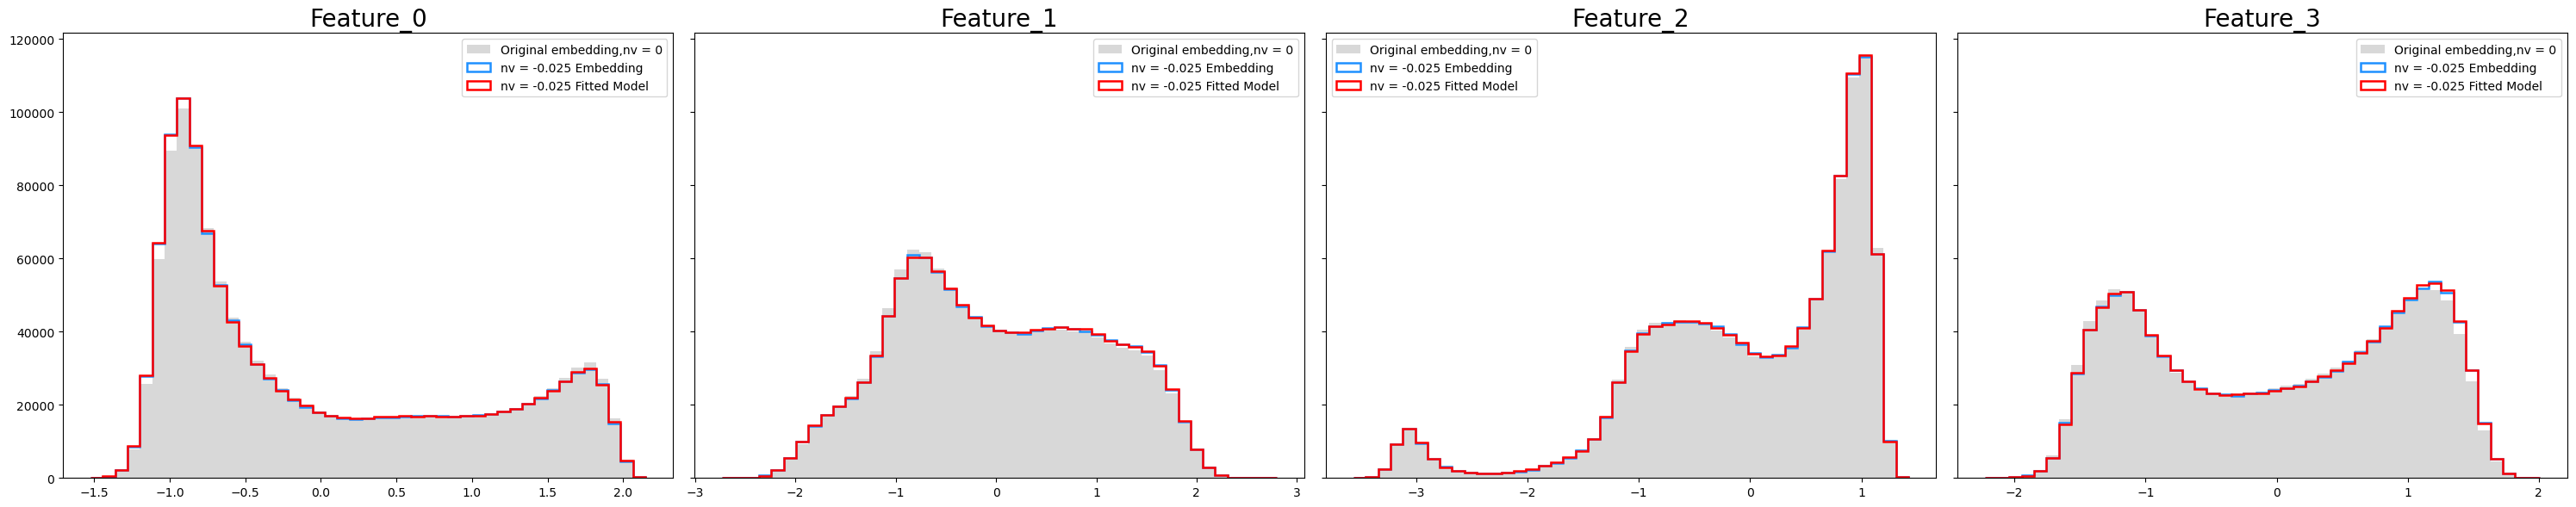

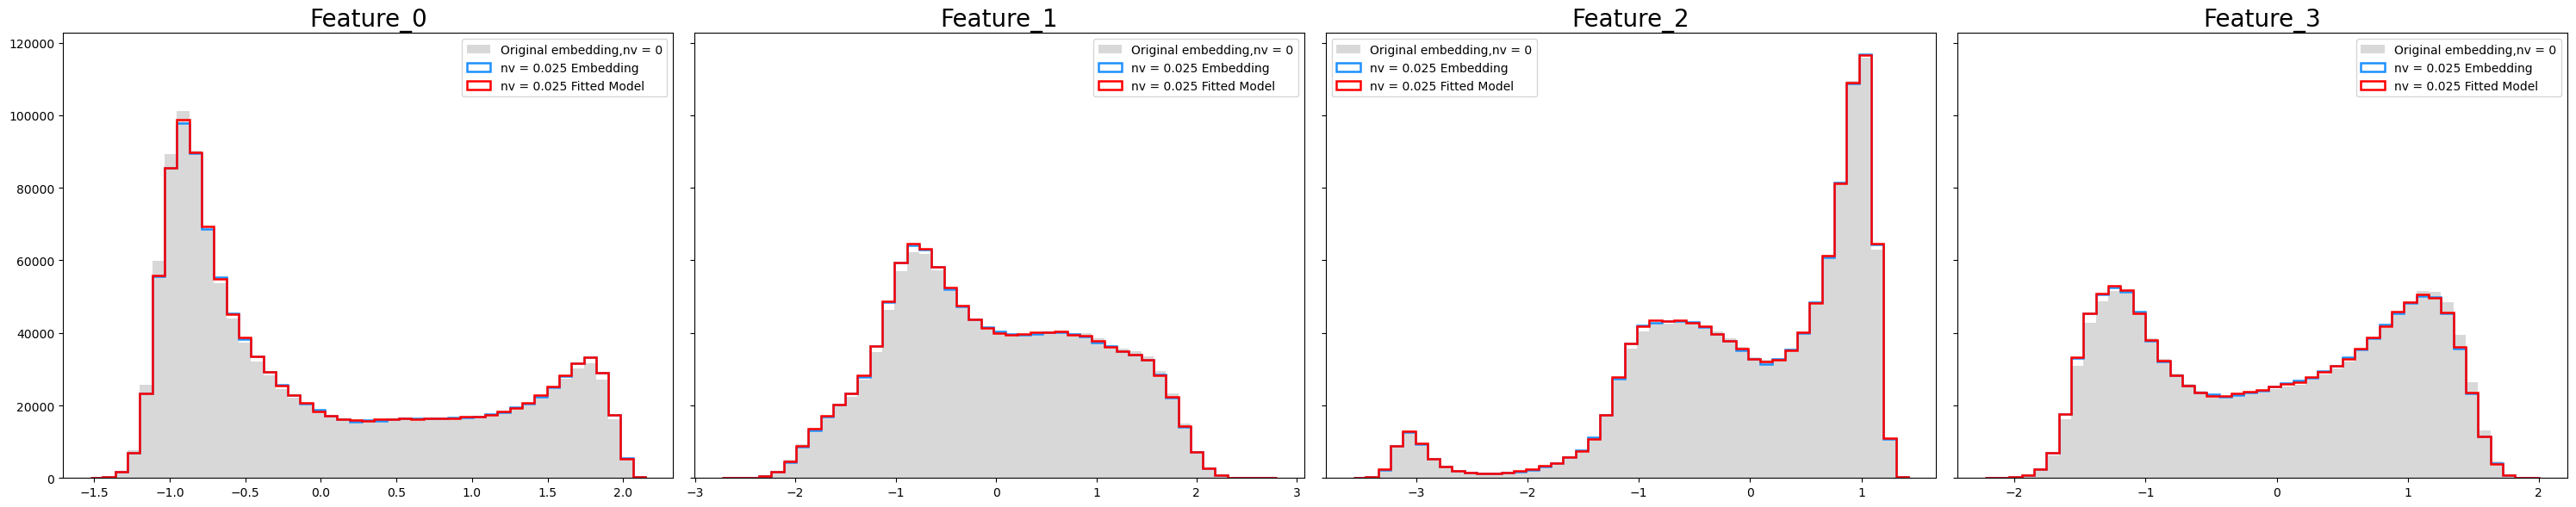

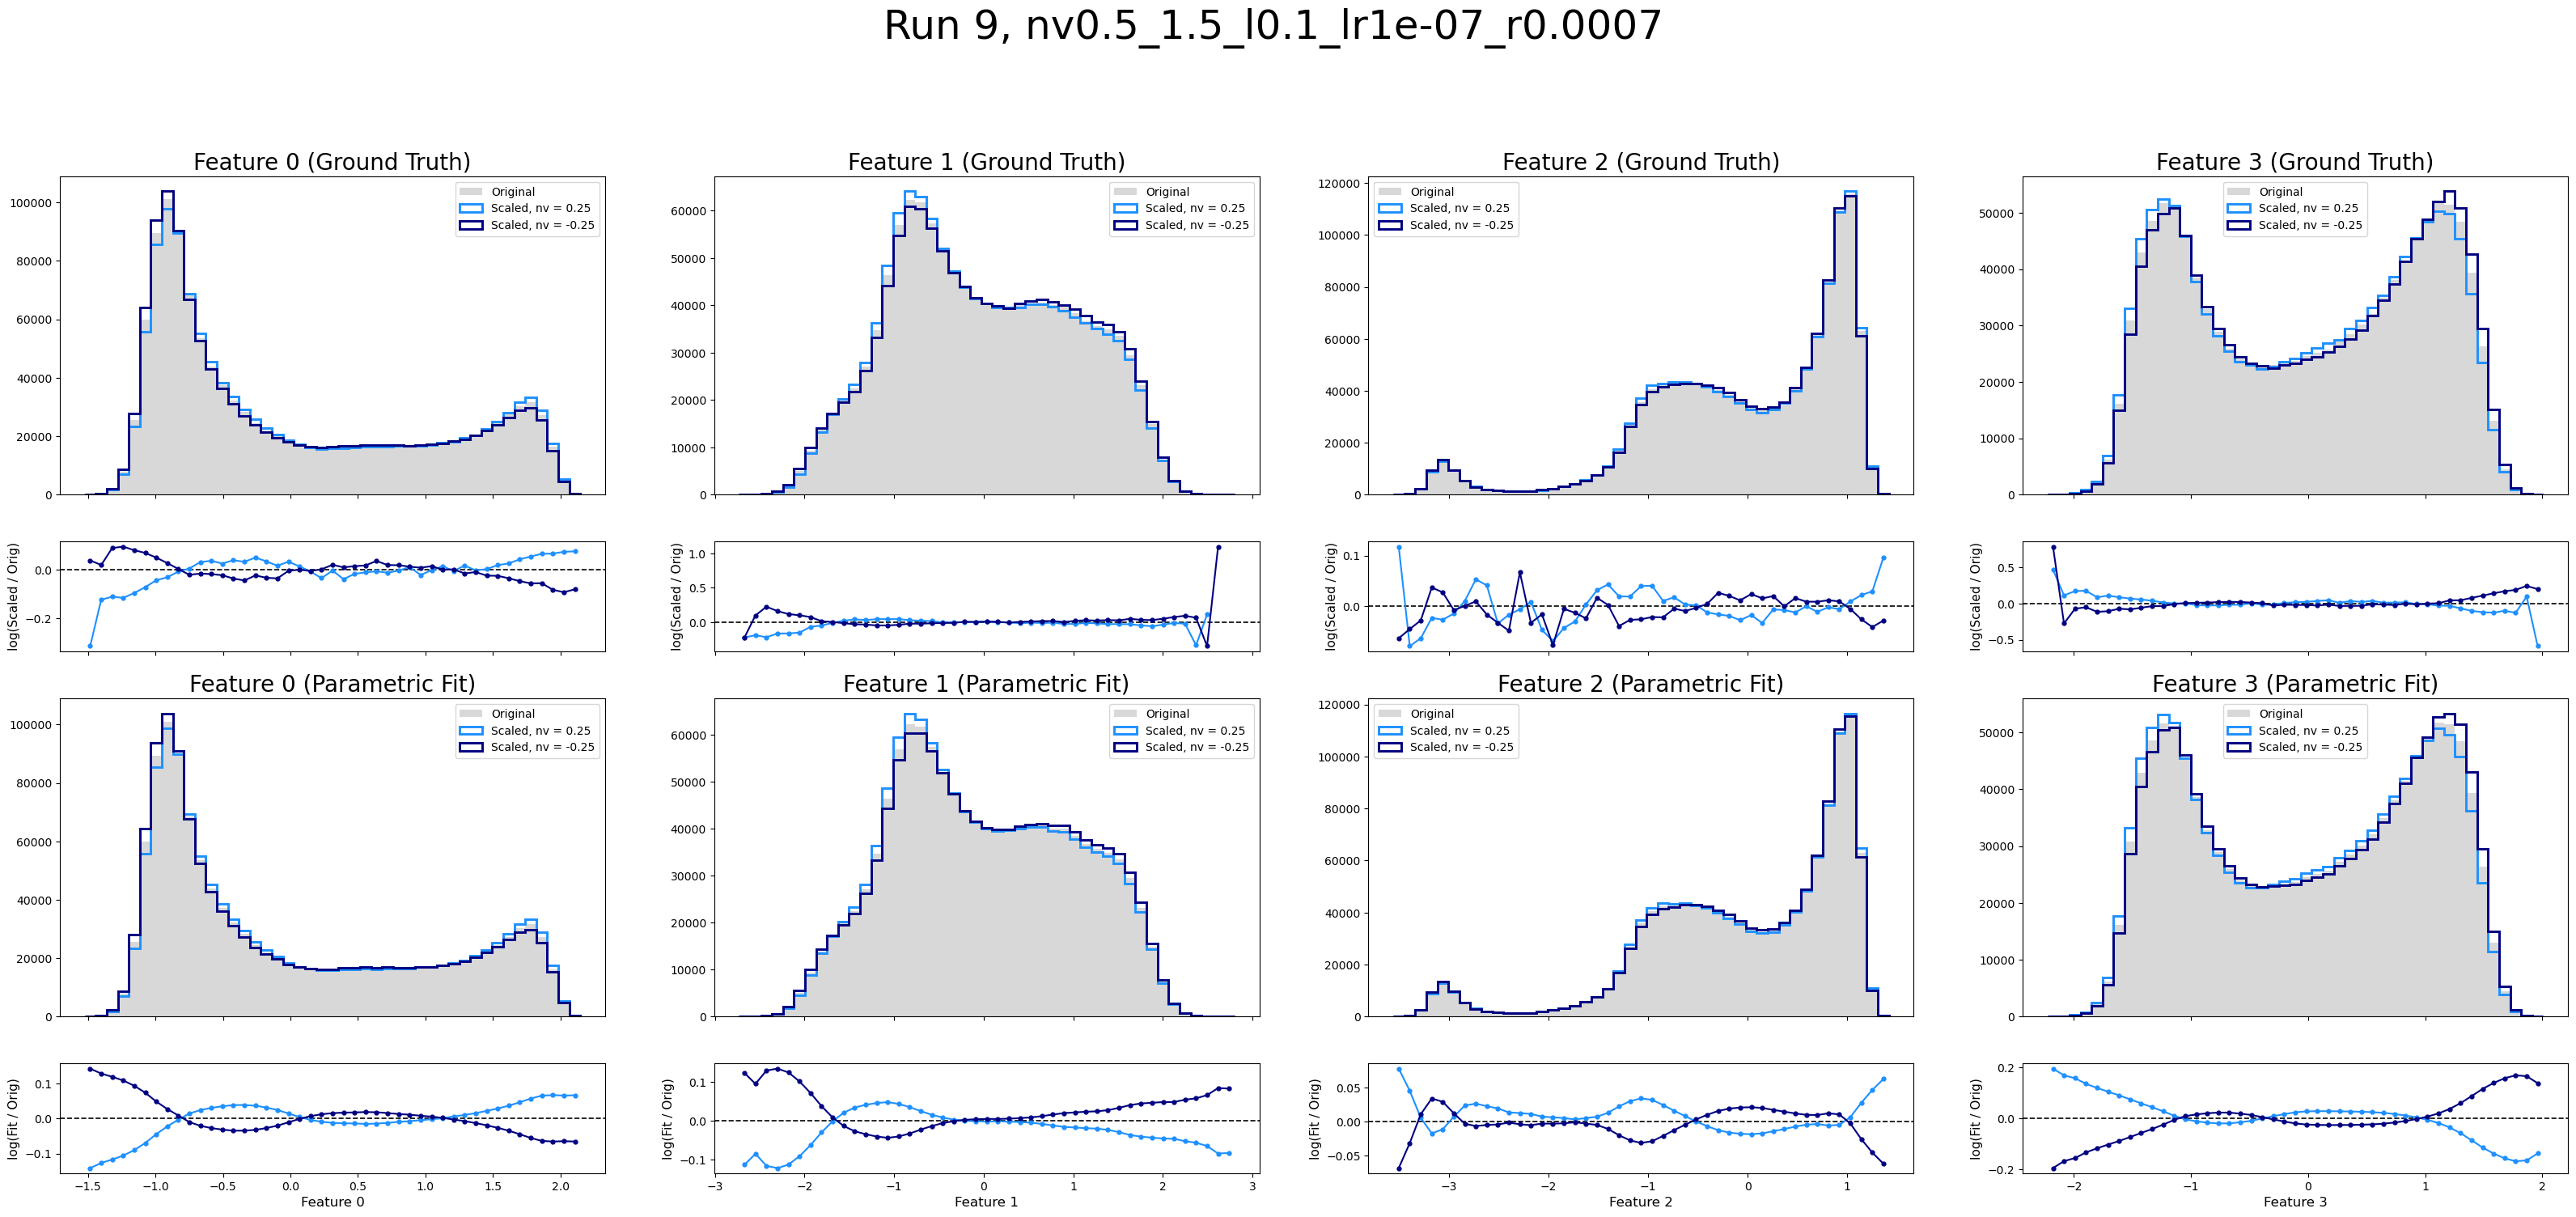

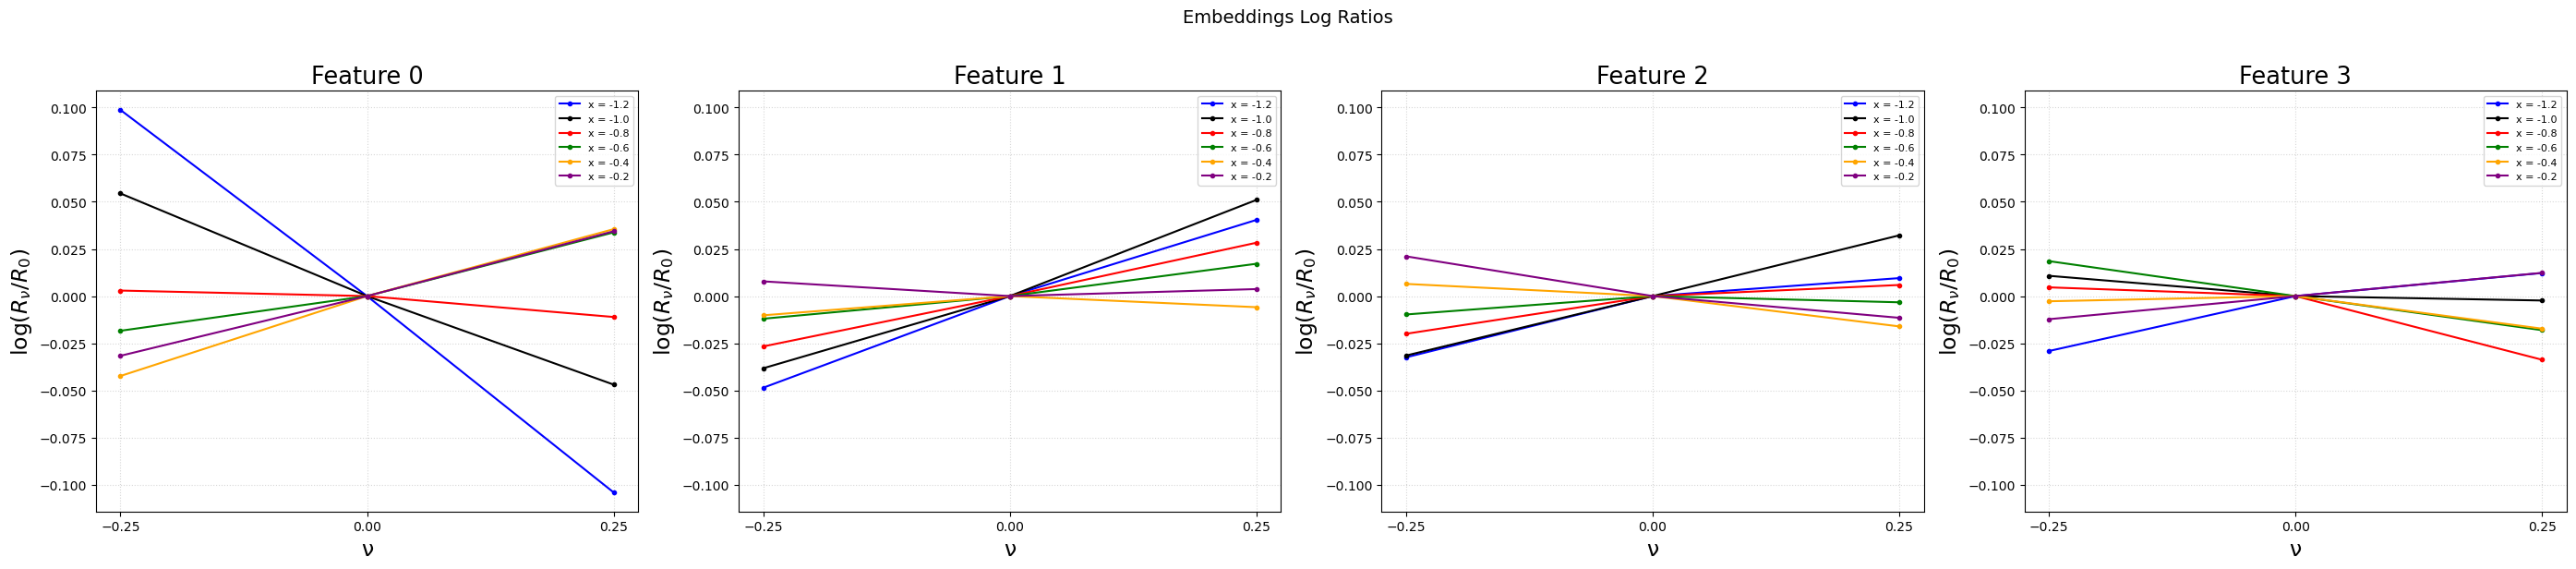

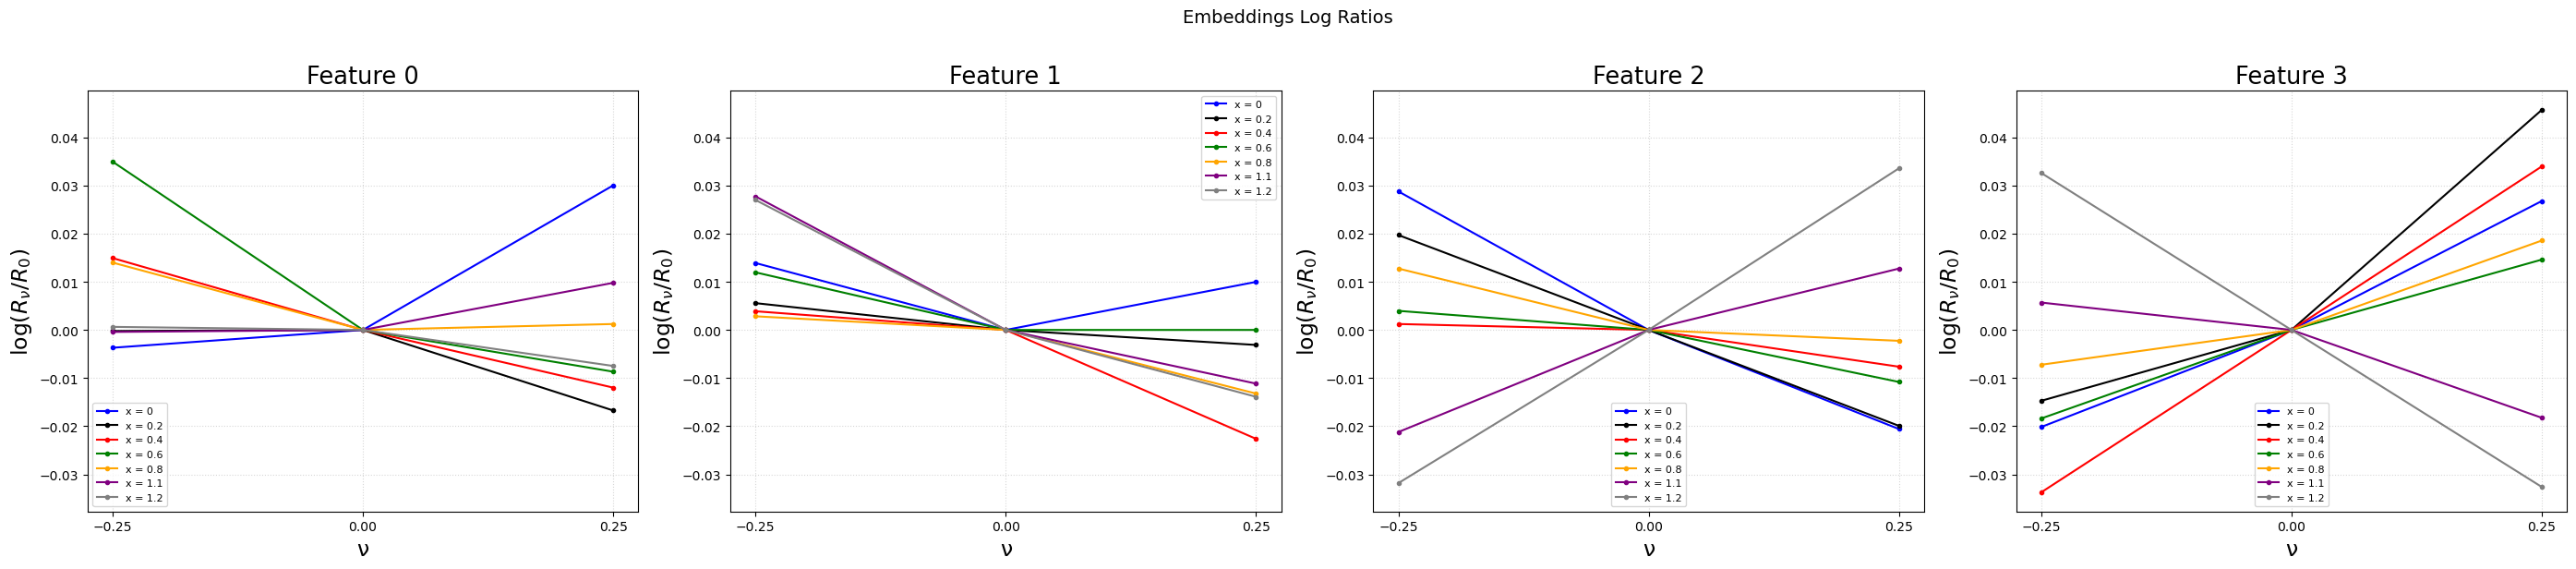


Feature 0:
 NV = -0.025:
   KS:  stat=0.0571429, p=1
   Chi2: stat=27.5194, p=0.776349, dof=34
   |Δcounts| sum = 6055.3,|counts| sum = 1.2e+06 and 1.20194e+06
   |Δcounts| = [ 15.21012127  38.31303823 234.0897342  252.99266994  83.97164059
 199.43635237 990.67914647 393.27872038  41.86936349 575.86829793
  50.13469434 137.00502503 216.84992141 366.46076244 105.42686671
 189.25379229 146.55030888  21.57454997  30.16304946 119.02719873
 286.11889362  19.29840946 247.06096631 112.44188118 290.89857411
  27.64141995 146.12625498  21.92248088 145.39228624 156.40487075
  80.85962188 150.49753624   2.59104449 142.04906172  17.84127724]
   |Δcounts|/|counts| = [1.92022446e-01 3.15252425e-02 2.92061277e-02 6.87106791e-03
 8.76997832e-04 1.54020886e-03 8.17920585e-03 4.69355196e-03
 6.76382861e-04 1.18855490e-02 1.25198596e-03 4.08945871e-03
 7.47324131e-03 1.42844851e-02 4.61981678e-03 8.77057959e-03
 6.99906664e-03 1.02969224e-03 1.40960929e-03 5.48815241e-03
 1.32733565e-02 8.86822519e-04 1

In [14]:
model.eval()
device = next(model.parameters()).device  
with torch.no_grad():
        fx_chunks = []
        for i in range(0, len(X), batch_size):
            xb = X[i:i+batch_size].to(device)
            tb = true[i:i+batch_size].to(device)
            with torch.no_grad():
                fxb = model(xb, tb)
            fx_chunks.append(fxb.cpu())
        fx = torch.cat(fx_chunks, dim=0)
        #fx = model(X,true)

nv_w0 = np.array([-0.25,0, 0.25])
fx_np    = to_np(fx) 

plot_reco_og(N_ref = nref, 
             N_Bkg_Pois=nbg, 
             fx = fx_np, 
             feature_np=feature,
             targets = target,
             nv_list = [-0.025,0.025])

plot_stephist(feature_np = feature,
              delta_np = fx_np, 
              targets = target,
              run_num = run_num, 
              run_series = 'nv0.5_1.5_l0.1_lr1e-07_r0.0007',
              nvs = nv, 
              N_Bkg_Pois = nbg, 
              N_ref = nref)

plot_log_sbs([feature], nbg, nref, nv_w0,
             [-1.2,-1.0,-0.8,-0.6,-0.4,-0.2])

plot_log_sbs([feature], nbg, nref, nv_w0,
             [0,0.2,0.4,0.6,0.8,1.1,1.2])
             
twosamples_tests(feature_np = feature, 
                 fx = fx_np , 
                 nv_only_val = [-0.025,0.025],
                 N_ref = nref, 
                 N_Bkg_Pois = nbg, 
                 targets = target,
                 bin_num=35)

In [15]:
torch.save(model.state_dict(),"/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/Run10.7/nv0.25_0.5_l0.5_lr2e-06_r1e-06/final_models/linear_3_final.pth")